In [1]:
import re
from collections import defaultdict
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

In [2]:
!pwd

/Users/neara_interview/Trace_projects/hens-hurricane/earth2studio/recipes/hens/notebooks


In [3]:
beryl_era5 = xr.open_dataset("../../../../data/beryl_outputs/beryl_era5.nc")

In [4]:
beryl_era5

<xarray.Dataset> Size: 17MB
Dimensions:                  (time: 1464, lat: 20, lon: 36, season: 1)
Coordinates:
  * time                     (time) datetime64[ns] 12kB 2024-06-01 ... 2024-0...
  * lat                      (lat) float64 160B 31.88 31.62 ... 27.38 27.12
  * lon                      (lon) float64 288B -98.88 -98.62 ... -90.38 -90.12
  * season                   (season) <U4 16B '2024'
Data variables:
    u_component_of_wind_10m  (time, lat, lon) float32 4MB ...
    v_component_of_wind_10m  (time, lat, lon) float32 4MB ...
    mean_sea_level_pressure  (time, lat, lon) float32 4MB ...
    wind_speed_10m           (season, time, lat, lon) float32 4MB ...

In [5]:
beryl_era5 = beryl_era5.isel(season=0).sel(time=slice("2024-07-05", "2024-07-15"))

In [6]:
beryl_era5 = beryl_era5[
    ['wind_speed_10m', 'mean_sea_level_pressure']
]

In [7]:
beryl_era5 = beryl_era5['wind_speed_10m'].sel(
    lon=slice(-95.8, -95.0),
    lat=slice(30.1, 29.5)
).mean(['lat', 'lon'])

In [8]:
output_dir = Path("../../../../data/hurricane_outputs/houston")

# Fixed global member ranges for each checkpoint seed
seed_offsets = {
    12: 0,
    16: 20,
    17: 40,
    18: 60,
}

files_by_init = {}

for path in output_dir.glob("*.nc"):
    match = re.search(
        r"hurricanes_(\d{4}-\d{2}-\d{2}T\d{2})_pkg_seed(\d+)\.nc$",
        path.name,
    )

    if match is None:
        continue

    init_time = match.group(1)
    seed = int(match.group(2))

    files_by_init.setdefault(init_time, []).append((seed, path))

all_initialisations = []

for init_time in sorted(files_by_init):
    checkpoint_datasets = []

    for seed, path in sorted(files_by_init[init_time]):
        ds = xr.open_dataset(path)

        n_members = ds.sizes["ensemble"]
        offset = seed_offsets[seed]

        ds = ds.assign_coords(
            ensemble=np.arange(offset, offset + n_members),
            seed=("ensemble", np.full(n_members, seed)),
        )

        checkpoint_datasets.append(ds)

    combined_init = xr.concat(
        checkpoint_datasets,
        dim="ensemble",
        coords="minimal",
        compat="override",
    )

    all_initialisations.append(combined_init)

tx = xr.concat(
    all_initialisations,
    dim="time",
    coords="minimal",
    compat="override"
)

In [9]:
print(tx)

<xarray.Dataset> Size: 5GB
Dimensions:    (ensemble: 80, time: 36, lead_time: 85, lat: 41, lon: 41)
Coordinates:
  * ensemble   (ensemble) int64 640B 0 1 2 3 4 5 6 7 ... 72 73 74 75 76 77 78 79
    seed       (ensemble) int64 640B 12 12 12 12 12 12 12 ... 18 18 18 18 18 18
  * time       (time) datetime64[ns] 288B 2002-06-01 2002-07-01 ... 2020-11-01
  * lead_time  (lead_time) timedelta64[ns] 680B 0 days 00:00:00 ... 21 days 0...
  * lat        (lat) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25.25 25.0
  * lon        (lon) float64 328B 260.0 260.2 260.5 260.8 ... 269.5 269.8 270.0
Data variables:
    u10m       (ensemble, time, lead_time, lat, lon) float32 2GB -3.181 ... -...
    v10m       (ensemble, time, lead_time, lat, lon) float32 2GB 3.511 ... 0....
    msl        (ensemble, time, lead_time, lat, lon) float32 2GB 1.009e+05 .....


In [10]:
tx['w10m'] = np.sqrt(tx['u10m'] ** 2 + tx['v10m'] ** 2)

In [71]:
# Compute wind direction in degrees (0° = North, 90° = East, 180° = South, 270° = West)
tx["wind_dir"] = (270.0 - np.degrees(np.arctan2(tx['v10m'], tx['u10m']))) % 360.0
tx["wind_dir"].attrs["units"] = "degrees_from_north"
tx["wind_dir"].attrs["long_name"] = "10m Wind Direction (Meteorological)"

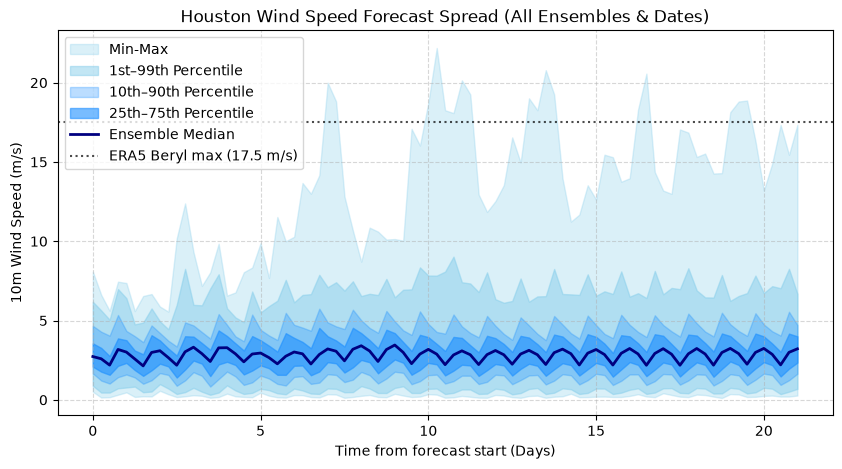

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Spatial average across Houston coordinates
# Houston metro bounding box
lat_min, lat_max = 29.5, 30.1
lon_min, lon_max = 264.2, 265.0  # -95.8 to -95.0 in 0–360 coordinates

# Select Houston region from the combined dataset
houston = tx["w10m"].sel(
    lat=slice(lat_max, lat_min),  # latitude is descending
    lon=slice(lon_min, lon_max),
)
houston_ds = houston.mean(["lat", "lon"])

# 2. Stack ensemble and time into a single 'realization' dimension (1440 realizations)
stacked = houston_ds.stack(realization=("ensemble", "time"))

# Convert lead_time to numeric days for the x-axis
lead_days = stacked.lead_time.dt.total_seconds() / 86400

# 3. Calculate percentiles along the 'realization' dimension natively in xarray
p_min = stacked.min(dim="realization").values
p1 = stacked.quantile(0.01, dim="realization").values
p10 = stacked.quantile(0.10, dim="realization").values
p25 = stacked.quantile(0.25, dim="realization").values
p50 = stacked.median(dim="realization").values
p75 = stacked.quantile(0.75, dim="realization").values
p90 = stacked.quantile(0.90, dim="realization").values
p99 = stacked.quantile(0.99, dim="realization").values
p_max = stacked.max(dim="realization").values

# 4. Plot Fan Chart
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded percentile ranges
ax.fill_between(
    lead_days, p_min, p_max, color="skyblue", alpha=0.3, label="Min-Max"
)
ax.fill_between(
    lead_days, p1, p99, color="skyblue", alpha=0.5, label="1st–99th Percentile"
)
ax.fill_between(
    lead_days, p10, p90, color="dodgerblue", alpha=0.3, label="10th–90th Percentile"
)
ax.fill_between(
    lead_days, p25, p75, color="dodgerblue", alpha=0.6, label="25th–75th Percentile"
)

# Median and Worst-Case Lines
ax.plot(lead_days, p50, color="navy", linewidth=2, label="Ensemble Median")
# ax.plot(
#     lead_days,
#     p_max,
#     color="crimson",
#     linestyle="--",
#     linewidth=1.5,
#     label="Max Worst-Case",
# )

# Reference Threshold line (e.g., Tropical Storm strength 17.5 m/s)
ax.axhline(
    17.5, color="black", linestyle=":", alpha=0.7, label="ERA5 Beryl max (17.5 m/s)"
)

ax.set_xlabel("Time from forecast start (Days)")
ax.set_ylabel("10m Wind Speed (m/s)")
ax.set_title("Houston Wind Speed Forecast Spread (All Ensembles & Dates)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

plt.show()

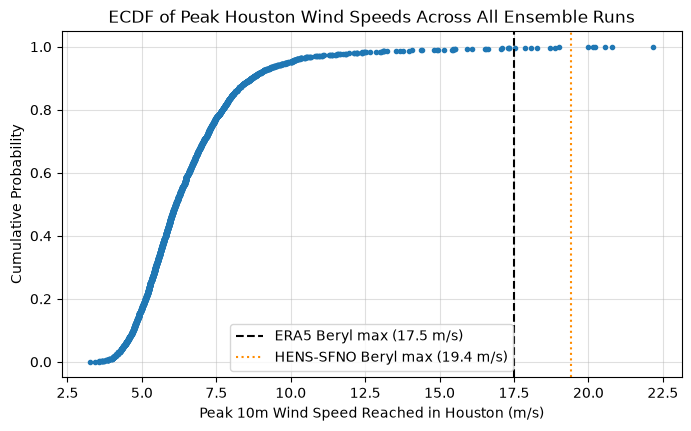

In [12]:
# Get the peak wind speed per realization
max_winds_per_sim = stacked.max(dim="lead_time").values

fig, ax = plt.subplots(figsize=(8, 4.5))

# Plot cumulative probability
sorted_winds = np.sort(max_winds_per_sim)
y_vals = np.arange(1, len(sorted_winds) + 1) / len(sorted_winds)

ax.plot(sorted_winds, y_vals, marker=".", linestyle="none", color="tab:blue")

ax.axvline(17.5, color="k", ls="--", label="ERA5 Beryl max (17.5 m/s)")
ax.axvline(19.4, color="darkorange", ls=":", label="HENS-SFNO Beryl max (19.4 m/s)")

ax.set_xlabel("Peak 10m Wind Speed Reached in Houston (m/s)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("ECDF of Peak Houston Wind Speeds Across All Ensemble Runs")
ax.grid(True, alpha=0.4)
ax.legend()

plt.show()

## Cyclone tracking

In [17]:
# ibtracs = pd.read_csv(
#     "../../../../data/beryl_outputs/ibtracs.NA.list.v04r01.csv",
#     low_memory=False,
#     skiprows=[1],
#     keep_default_na=False,
#     # parse_dates=True
#     )

In [18]:
# ibtracs = ibtracs[
#     (ibtracs.BASIN == "NA") &
#     (ibtracs.SEASON >= 1980)
# ].copy()

In [19]:
# ibtracs['ISO_TIME'] = pd.to_datetime(ibtracs['ISO_TIME'])

In [20]:
# cols = [
#     "SID", "SEASON", "NAME", "ISO_TIME",
#     "LAT", "LON", "USA_STATUS",
#     # "USA_SSHS",
#     "USA_WIND", "USA_PRES",
#     # "USA_R34_NE", "USA_R34_SE", "USA_R34_SW", "USA_R34_NW",
#     # "USA_R64_NE", "USA_R64_SE", "USA_R64_SW", "USA_R64_NW",
#     # "DIST2LAND", "LANDFALL",
# ]

# ibtracs = ibtracs[cols].copy()

In [21]:
# gdf = gpd.GeoDataFrame(
#     ibtracs.copy(),
#     geometry=gpd.points_from_xy(
#         ibtracs["LON"],
#         ibtracs["LAT"]
#     ),
#     crs="EPSG:4326"
# ).to_crs("EPSG:5070")

In [22]:
# print(gdf)

In [13]:
root = Path("../../../../data/hurricane_outputs/cyclones")

# Group files by initialisation time
files_by_init = defaultdict(list)

for file in sorted(root.glob("**/*.nc")):
    match = re.search(
        r"tracks_pkg_(\d+)_(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})_batch_(\d+)\.nc$",
        file.name,
    )

    if match is None:
        # print("Skipped:", file)
        continue

    seed = int(match.group(1))
    init_time = match.group(2)
    batch = int(match.group(3))

    files_by_init[init_time].append((seed, batch, file))

# Combine batches for each initialisation
tracks_by_init = {}

for init_time, items in sorted(files_by_init.items()):
    arrays = []

    for seed, batch, file in sorted(items, key=lambda x: (x[0], x[1])):
        # print("Opening:", file)

        da = xr.open_dataarray(file)

        # Preserve the checkpoint seed
        da = da.assign_coords(
            seed=("ensemble", np.full(da.sizes["ensemble"], seed))
        )

        arrays.append(da)

    # Concatenate batch/member files
    tracks_by_init[init_time] = xr.concat(
        arrays,
        dim="ensemble",
        coords="minimal",
        compat="override",
    )

/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_60932/76808048.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_by_init[init_time] = xr.concat(
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_60932/76808048.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_by_init[init_time] = xr.concat(
/var/folders/4w/

In [14]:
tracks_all = xr.concat(
    list(tracks_by_init.values()),
    dim="time",
    coords="minimal",
    compat="override",
)

/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_60932/2546155076.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_all = xr.concat(


In [15]:
print(tracks_all)

<xarray.DataArray (ensemble: 80, time: 36, path_id: 99, step: 85, variable: 4)> Size: 776MB
array([[[[[4.85836926e+01, 2.92419361e+01, 1.01091219e+05,
           5.36012840e+00],
          [           nan,            nan,            nan,
                      nan],
          [           nan,            nan,            nan,
                      nan],
          ...,
          [           nan,            nan,            nan,
                      nan],
          [           nan,            nan,            nan,
                      nan],
          [           nan,            nan,            nan,
                      nan]],

         [[3.98677147e+01, 8.04309118e+01, 1.00142117e+05,
           6.03038168e+00],
          [           nan,            nan,            nan,
                      nan],
          [           nan,            nan,            nan,
                      nan],
...
          [           nan,            nan,            nan,
                      nan],
          [      

<>:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_60932/1323069605.py:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",


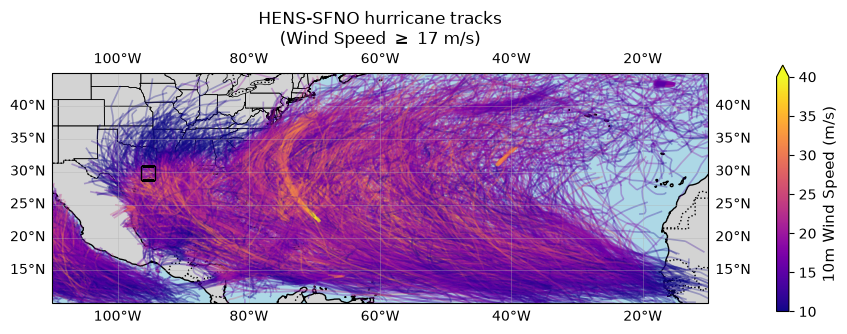

In [18]:
# -------------------------------------------------------------------------
# 1. Process IBTrACS GeoDataFrame for Hurricane Beryl
# -------------------------------------------------------------------------
# # Filter Beryl (ensure ISO_TIME is datetime)
# beryl_df = gdf[gdf["NAME"].str.upper() == "BERYL"].copy()
# beryl_df["ISO_TIME"] = pd.to_datetime(beryl_df["ISO_TIME"])

# # Filter for the relevant period matching your forecast window (e.g., July 2024)
# beryl_df = beryl_df[
#     (beryl_df["ISO_TIME"] >= "2024-07-01")
#     & (beryl_df["ISO_TIME"] <= "2024-07-15")
# ].sort_values("ISO_TIME")

# # Use direct numeric LAT/LON coordinates for Cartopy (to bypass metric geometry projection issues)
# beryl_lon = beryl_df["LON"].values
# beryl_lat = beryl_df["LAT"].values
# # Convert knots (USA_WIND) to m/s if necessary (1 knot ≈ 0.514444 m/s)
# beryl_wind = beryl_df["USA_WIND"].astype(float).values * 0.514444

# -------------------------------------------------------------------------
# 2. Process Ensemble Tracker Data
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Map setup
ax.set_extent([-110, -10, 10, 45], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Wind speed colormap bounds
vmin, vmax = 10, 40
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

ensembles = tracks_all.ensemble.values
times = tracks_all.time.values
paths = tracks_all.path_id.values

# -------------------------------------------------------------------------
# 3. Plot Ensemble Tracks (With Jump & Zero-Filtering)
# -------------------------------------------------------------------------
for ensemble_idx in range(len(ensembles)):
    for time_idx in range(len(times)):
        for path_idx in range(len(paths)):

            x = lon[ensemble_idx, time_idx, path_idx, :]
            y = lat[ensemble_idx, time_idx, path_idx, :]
            w = wind[ensemble_idx, time_idx, path_idx, :]

            # Filter tracks with max wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            # 1. Mask NaNs AND invalid 0.0 lat/lon padding entries
            valid = (
                ~np.isnan(x)
                & ~np.isnan(y)
                & ~np.isnan(w)
                & (x != 0.0)
                & (y != 0.0)
            )
            x_v, y_v, w_v = x[valid], y[valid], w[valid]

            if len(x_v) < 2:
                continue

            # 2. Remove non-physical jumps across the 180°/360° boundary (> 5 degrees per step)
            lon_diffs = np.abs(np.diff(x_v))
            lat_diffs = np.abs(np.diff(y_v))
            clean_steps = np.ones(len(x_v) - 1, dtype=bool)
            clean_steps[
                (lon_diffs > 5.0) | (lat_diffs > 5.0)
            ] = False  # Flag artificial jumps

            # Build line segments only for valid consecutive steps
            points = np.array([x_v, y_v]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Keep only clean segments
            segments = segments[clean_steps]
            w_segments = w_v[:-1][clean_steps]

            if len(segments) == 0:
                continue

            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidth=1.2,
                alpha=0.3,
                transform=projection,
            )
            lc.set_array(w_segments)
            ax.add_collection(lc)

# -------------------------------------------------------------------------
# 4. Plot IBTrACS Beryl Track On Top
# -------------------------------------------------------------------------
# if len(beryl_lon) > 1:
#     # Option A: Color-coded track line for Beryl
#     valid_b = ~np.isnan(beryl_lon) & ~np.isnan(beryl_lat) & ~np.isnan(beryl_wind)
#     bx_v, by_v, bw_v = (
#         beryl_lon[valid_b],
#         beryl_lat[valid_b],
#         beryl_wind[valid_b],
#     )

#     b_points = np.array([bx_v, by_v]).T.reshape(-1, 1, 2)
#     b_segments = np.concatenate([b_points[:-1], b_points[1:]], axis=1)

#     lc_beryl = LineCollection(
#         b_segments,
#         cmap=cmap,
#         norm=norm,
#         linewidth=3.5,
#         zorder=5,
#         transform=projection,
#     )
#     lc_beryl.set_array(bw_v[:-1])
#     ax.add_collection(lc_beryl)

#     # Option B: High-contrast black dashed outline for clarity
#     ax.plot(
#         bx_v,
#         by_v,
#         color="black",
#         linestyle="--",
#         linewidth=1.2,
#         zorder=6,
#         transform=projection,
#         label="IBTrACS (Beryl)",
#     )

#     # Scatter points along Beryl's track
#     ax.scatter(
#         bx_v,
#         by_v,
#         c=bw_v,
#         cmap=cmap,
#         norm=norm,
#         edgecolor="black",
#         linewidth=0.5,
#         s=30,
#         zorder=7,
#         transform=projection,
#     )

# -------------------------------------------------------------------------
# 5. Legend, Colorbar & Titles
# -------------------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.4, pad=0.08, extend="max")
cbar.set_label("10m Wind Speed (m/s)", fontsize=11)

# Houston coordinates
houston_lon, houston_lat = -95.37, 29.76

# Draw a square box at Houston's location
ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="k",
    markerfacecolor="none",
    markersize=10,
    markeredgewidth=1.,
    zorder=8,
    transform=projection,
)

# Annotate with a black line pointing from the bottom-right corner of the Houston box
# ax.annotate(
#     "Houston",
#     xy=(houston_lon+.3, houston_lat),  # Point to target coordinates
#     xytext=(houston_lon + 3.5, houston_lat - 2.5),  # Text location (offset to lower-right)
#     xycoords=projection._as_mpl_transform(ax),  # Geographic coordinates transform
#     textcoords=projection._as_mpl_transform(ax),
#     fontsize=11,
#     # fontweight="bold",
#     color="black",
#     zorder=10,
#     arrowprops=dict(
#         arrowstyle="-",            # Simple straight line without arrow head
#         color="black",
#         linewidth=1.5,
#         patchA=None,
#         relpos=(0.0, 1.0),         # Connect line to top-left of text
#         shrinkA=7,                 # Offset start point to align with bottom-right corner of the marker box
#     ),
# )

ax.set_title(
    "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",
    fontsize=12,
)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
# ax.legend(loc="upper right", framealpha=0.9)

plt.show()

<>:236: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:236: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_60932/2129633348.py:236: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",


Total tracks meeting wind threshold (>= 17 m/s): 25549
Tracks plotted within bounding box [-110, -80, 10, 45]: 2958


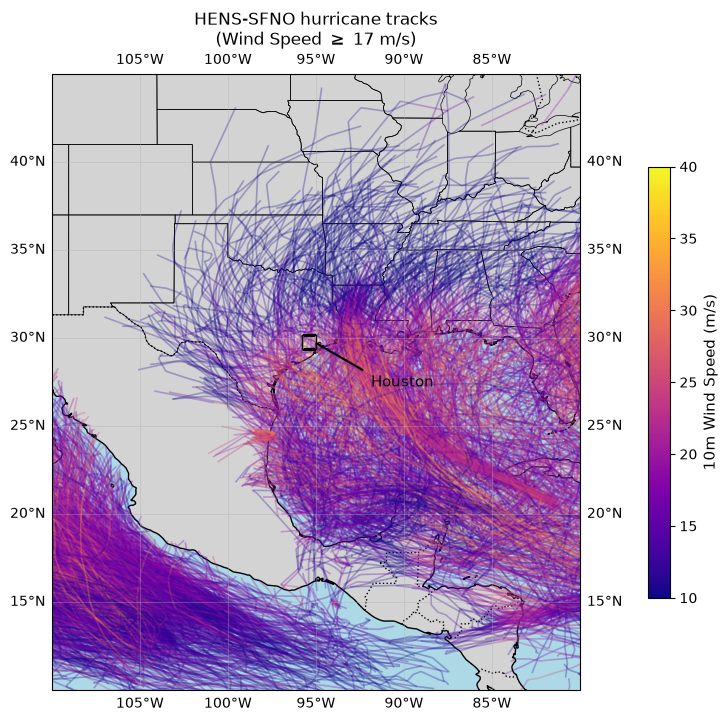

In [36]:
# -------------------------------------------------------------------------
# 1. Process IBTrACS GeoDataFrame for Hurricane Beryl
# -------------------------------------------------------------------------
# # Filter Beryl (ensure ISO_TIME is datetime)
# beryl_df = gdf[gdf["NAME"].str.upper() == "BERYL"].copy()
# beryl_df["ISO_TIME"] = pd.to_datetime(beryl_df["ISO_TIME"])

# # Filter for the relevant period matching your forecast window (e.g., July 2024)
# beryl_df = beryl_df[
#     (beryl_df["ISO_TIME"] >= "2024-07-01")
#     & (beryl_df["ISO_TIME"] <= "2024-07-15")
# ].sort_values("ISO_TIME")

# # Use direct numeric LAT/LON coordinates for Cartopy (to bypass metric geometry projection issues)
# beryl_lon = beryl_df["LON"].values
# beryl_lat = beryl_df["LAT"].values
# # Convert knots (USA_WIND) to m/s if necessary (1 knot ≈ 0.514444 m/s)
# beryl_wind = beryl_df["USA_WIND"].astype(float).values * 0.514444

# -------------------------------------------------------------------------
# 2. Process Ensemble Tracker Data
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Map setup
ax.set_extent([-110, -80, 10, 45], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Wind speed colormap bounds
vmin, vmax = 10, 40
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

ensembles = tracks_all.ensemble.values
times = tracks_all.time.values
paths = tracks_all.path_id.values

# Map extent bounds
min_lon, max_lon = -110, -80
min_lat, max_lat = 10, 45

plotted_track_count = 0
total_qualified_tracks = 0

# -------------------------------------------------------------------------
# 3. Plot Ensemble Tracks (With Spatial Bounding Check)
# -------------------------------------------------------------------------
for ensemble_idx in range(len(ensembles)):
    for time_idx in range(len(times)):
        for path_idx in range(len(paths)):

            x = lon[ensemble_idx, time_idx, path_idx, :]
            y = lat[ensemble_idx, time_idx, path_idx, :]
            w = wind[ensemble_idx, time_idx, path_idx, :]

            # Filter tracks with max wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            # 1. Mask NaNs AND invalid 0.0 lat/lon padding entries
            valid = (
                ~np.isnan(x)
                & ~np.isnan(y)
                & ~np.isnan(w)
                & (x != 0.0)
                & (y != 0.0)
            )
            x_v, y_v, w_v = x[valid], y[valid], w[valid]

            if len(x_v) < 2:
                continue

            # 2. Remove non-physical jumps across the 180°/360° boundary (> 5 degrees per step)
            lon_diffs = np.abs(np.diff(x_v))
            lat_diffs = np.abs(np.diff(y_v))
            clean_steps = np.ones(len(x_v) - 1, dtype=bool)
            clean_steps[(lon_diffs > 5.0) | (lat_diffs > 5.0)] = False

            # Build line segments only for valid consecutive steps
            points = np.array([x_v, y_v]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Keep only clean segments
            segments = segments[clean_steps]
            w_segments = w_v[:-1][clean_steps]

            if len(segments) == 0:
                continue

            total_qualified_tracks += 1

            # 3. SPATIAL CHECK: Verify if ANY segment point falls within the bounding box
            in_bbox = (
                (x_v >= min_lon)
                & (x_v <= max_lon)
                & (y_v >= min_lat)
                & (y_v <= max_lat)
            )

            if not np.any(in_bbox):
                continue  # Skip tracks outside the map extent

            plotted_track_count += 1

            # Draw the LineCollection
            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidth=1.2,
                alpha=0.3,
                transform=projection,
            )
            lc.set_array(w_segments)
            ax.add_collection(lc)

print(f"Total tracks meeting wind threshold (>= 17 m/s): {total_qualified_tracks}")
print(
    f"Tracks plotted within bounding box [{min_lon}, {max_lon}, {min_lat}, {max_lat}]: {plotted_track_count}"
)

# -------------------------------------------------------------------------
# 4. Plot IBTrACS Beryl Track On Top
# -------------------------------------------------------------------------
# if len(beryl_lon) > 1:
#     # Option A: Color-coded track line for Beryl
#     valid_b = ~np.isnan(beryl_lon) & ~np.isnan(beryl_lat) & ~np.isnan(beryl_wind)
#     bx_v, by_v, bw_v = (
#         beryl_lon[valid_b],
#         beryl_lat[valid_b],
#         beryl_wind[valid_b],
#     )

#     b_points = np.array([bx_v, by_v]).T.reshape(-1, 1, 2)
#     b_segments = np.concatenate([b_points[:-1], b_points[1:]], axis=1)

#     lc_beryl = LineCollection(
#         b_segments,
#         cmap=cmap,
#         norm=norm,
#         linewidth=3.5,
#         zorder=5,
#         transform=projection,
#     )
#     lc_beryl.set_array(bw_v[:-1])
#     ax.add_collection(lc_beryl)

#     # Option B: High-contrast black dashed outline for clarity
#     ax.plot(
#         bx_v,
#         by_v,
#         color="black",
#         linestyle="--",
#         linewidth=1.2,
#         zorder=6,
#         transform=projection,
#         label="IBTrACS (Beryl)",
#     )

#     # Scatter points along Beryl's track
#     ax.scatter(
#         bx_v,
#         by_v,
#         c=bw_v,
#         cmap=cmap,
#         norm=norm,
#         edgecolor="black",
#         linewidth=0.5,
#         s=30,
#         zorder=7,
#         transform=projection,
#     )

# -------------------------------------------------------------------------
# 5. Legend, Colorbar & Titles
# -------------------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.7, pad=0.08)
cbar.set_label("10m Wind Speed (m/s)", fontsize=11)

# Houston coordinates
houston_lon, houston_lat = -95.37, 29.76

# Draw a square box at Houston's location
ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="k",
    markerfacecolor="none",
    markersize=10,
    markeredgewidth=1.,
    zorder=8,
    transform=projection,
)

# Annotate with a black line pointing from the bottom-right corner of the Houston box
ax.annotate(
    "Houston",
    xy=(houston_lon+.3, houston_lat),  # Point to target coordinates
    xytext=(houston_lon + 3.5, houston_lat - 2.5),  # Text location (offset to lower-right)
    xycoords=projection._as_mpl_transform(ax),  # Geographic coordinates transform
    textcoords=projection._as_mpl_transform(ax),
    fontsize=11,
    # fontweight="bold",
    color="black",
    zorder=10,
    arrowprops=dict(
        arrowstyle="-",            # Simple straight line without arrow head
        color="black",
        linewidth=1.5,
        patchA=None,
        relpos=(0.0, 1.0),         # Connect line to top-left of text
        shrinkA=7,                 # Offset start point to align with bottom-right corner of the marker box
    ),
)

ax.set_title(
    "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",
    fontsize=12,
)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
# ax.legend(loc="upper right", framealpha=0.9)

plt.show()

<>:106: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:106: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_60932/104097726.py:106: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar.set_label("Unique Cyclone Track Passages (per $0.5^\circ$ cell)", fontsize=11)


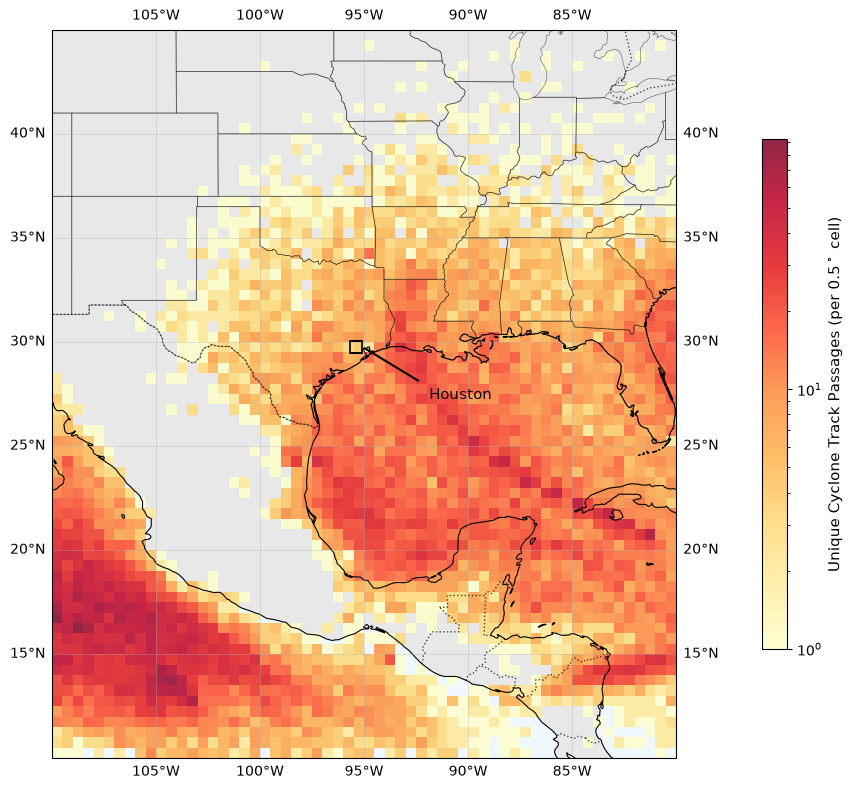

In [40]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------------
# 1. Process Tracks & Bin Unique Passages
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

num_ensembles, num_times, num_paths, _ = lat.shape

# Map domain bounds
lon_min, lon_max = -110, -80
lat_min, lat_max = 10, 45
grid_res = 0.5  # 0.5-degree resolution gives cleaner statistical density

lon_bins = np.arange(lon_min, lon_max + grid_res, grid_res)
lat_bins = np.arange(lat_min, lat_max + grid_res, grid_res)

# Accumulator grid for unique track passages
track_density = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

for ens in range(num_ensembles):
    for t in range(num_times):
        for p in range(num_paths):
            w = wind[ens, t, p, :]

            # Filter tracks where max wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            x = lon[ens, t, p, :]
            y = lat[ens, t, p, :]

            valid = (
                ~np.isnan(x)
                & ~np.isnan(y)
                & ~np.isnan(w)
                & (x != 0.0)
                & (y != 0.0)
            )
            x_v, y_v = x[valid], y[valid]

            if len(x_v) < 2:
                continue

            # Remove non-physical jumps (> 5 deg/step)
            lon_diffs = np.abs(np.diff(x_v))
            lat_diffs = np.abs(np.diff(y_v))
            clean_mask = np.ones(len(x_v), dtype=bool)
            jumps = np.where((lon_diffs > 5.0) | (lat_diffs > 5.0))[0]
            if len(jumps) > 0:
                clean_mask[jumps + 1] = False

            x_v, y_v = x_v[clean_mask], y_v[clean_mask]

            # Bin THIS INDIVIDUAL TRACK into the 2D grid
            H, _, _ = np.histogram2d(y_v, x_v, bins=[lat_bins, lon_bins])

            # Convert to binary mask (1 = this track passed through cell, 0 = didn't)
            # This ensures 1 track = 1 count per cell regardless of speed
            track_density += H > 0

# Mask 0 values so background ocean remains clean
density_masked = np.ma.masked_where(track_density == 0, track_density)

# -------------------------------------------------------------------------
# 2. Plot Density Heatmap
# -------------------------------------------------------------------------
projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey", alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)

# Pcolormesh using un-smoothed unique track counts
mesh = ax.pcolormesh(
    lon_bins,
    lat_bins,
    density_masked,
    cmap="YlOrRd",
    norm=mcolors.LogNorm(
        vmin=1, vmax=np.max(track_density)
    ),  # Log scale highlights rare tracks
    shading="flat",
    alpha=0.85,
    transform=projection,
)

cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.7, pad=0.08)
cbar.set_label("Unique Cyclone Track Passages (per $0.5^\circ$ cell)", fontsize=11)

# Houston Marker & Annotation
houston_lon, houston_lat = -95.37, 29.76

ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="black",
    markerfacecolor="none",
    markersize=9,
    markeredgewidth=1.2,
    zorder=8,
    transform=projection,
)

ax.annotate(
    "Houston",
    xy=(houston_lon + 0.3, houston_lat),
    xytext=(houston_lon + 3.5, houston_lat - 2.5),
    xycoords=projection._as_mpl_transform(ax),
    textcoords=projection._as_mpl_transform(ax),
    fontsize=11,
    color="black",
    zorder=9,
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        linewidth=1.5,
        shrinkA=7,
        relpos=(0.0, 1.0),
    ),
)

# ax.set_title(
#     "HENS-SFNO Unique Track Density ($\ge$17 m/s)", fontsize=12, pad=10
# )
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [51]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # -------------------------------------------------------------------------
# # 1. Prepare Houston Peak Wind Speeds & Extract Initialization Years
# # -------------------------------------------------------------------------
# houston_ds = houston.mean(["lat", "lon"])

# # Stack to get all realizations (ensemble * initialization time)
# stacked = houston_ds.stack(realization=("ensemble", "time"))

# # Extract maximum wind speed across lead_time
# peak_da = stacked.max(dim="lead_time")
# peak_winds = peak_da.values

# # Extract initialization year for each realization
# years = pd.to_datetime(peak_da.time.values).year
# n_samples = len(peak_winds)

# # -------------------------------------------------------------------------
# # 2. Calculate Empirical Exceedance Probabilities & Return Periods
# # -------------------------------------------------------------------------
# # Sort peak winds in descending order and reorder years accordingly
# sort_idx = np.argsort(peak_winds)[::-1]
# sorted_winds = peak_winds[sort_idx]
# sorted_years = years[sort_idx]

# # Rank order (1 to N)
# ranks = np.arange(1, n_samples + 1)

# # Exceedance probability P(X >= x) using Weibull plotting position
# exceedance_prob = ranks / (n_samples + 1)

# # Return Period / Synthetic Frequency
# return_period = 1 / exceedance_prob

# # -------------------------------------------------------------------------
# # 3. Plot Exceedance Return Period Points Grouped by ENSO Phase
# # -------------------------------------------------------------------------
# fig, ax = plt.subplots(figsize=(10, 6))

# # Map years to aggregated ENSO phase categories
# enso_groups = {
#     "El Niño": ([2002, 2015], "tab:red"),
#     "La Niña": ([2010, 2020], "tab:blue"),
#     "Neutral": ([2005, 2019], "gray"),
# }

# # Plot grouped points for each ENSO phase
# for phase_name, (phase_years, color) in enso_groups.items():
#     mask = np.isin(sorted_years, phase_years)
#     if np.any(mask):
#         ax.scatter(
#             return_period[mask],
#             sorted_winds[mask],
#             color=color,
#             s=15,
#             alpha=0.75,
#             label=f"{phase_name} (n={mask.sum()})",
#             zorder=3,
#         )

# # Fallback plot for any unclassified years if present
# classified_years = [y for yrs, _ in enso_groups.values() for y in yrs]
# other_mask = ~np.isin(sorted_years, classified_years)
# if np.any(other_mask):
#     ax.scatter(
#         return_period[other_mask],
#         sorted_winds[other_mask],
#         color="lightgray",
#         s=10,
#         alpha=0.5,
#         label=f"Other Years (n={other_mask.sum()})",
#         zorder=2,
#     )

# # Set logarithmic scale on X-axis to emphasize rare tail events
# ax.set_xscale("log")

# # -------------------------------------------------------------------------
# # 4. Highlight Beryl & Key Risk Thresholds
# # -------------------------------------------------------------------------
# beryl_obs_wind = 17.5

# # # Reference wind thresholds
# # ax.axhline(
# #     17.5,
# #     color="gray",
# #     linestyle="--",
# #     linewidth=1,
# #     alpha=0.7,
# #     label="ERA5 Beryl (17.5 m/s)",
# # )
# # ax.axhline(
# #     19.4,
# #     color="darkorange",
# #     linestyle="--",
# #     linewidth=1,
# #     alpha=0.7,
# #     label="HENS-SFNO Beryl max (19.4 m/s)",
# # )

# # Highlight Beryl on the curve
# if beryl_obs_wind <= sorted_winds.max():
#     idx = np.argmin(np.abs(sorted_winds - beryl_obs_wind))
#     beryl_rp = return_period[idx]

#     ax.plot(
#         beryl_rp,
#         beryl_obs_wind,
#         marker="s",
#         color="gray",
#         markersize=6,
#         ls="None",
#         zorder=5,
#         label=f"ERA5 Beryl Peak (~{beryl_obs_wind} m/s)",
#     )

#     # Annotate Beryl
#     ax.annotate(
#         f"Hurricane Beryl (Neutral)\n(Top {exceedance_prob[idx]*100:.1f}% event)",
#         xy=(beryl_rp, beryl_obs_wind),
#         xytext=(beryl_rp * 0.3, beryl_obs_wind + 2),
#         arrowprops=dict(arrowstyle="->", color="crimson", linewidth=1.5),
#         fontsize=10,
#         color="k",
#     )

# # -------------------------------------------------------------------------
# # 5. Formatting & Annotations
# # -------------------------------------------------------------------------
# ax.set_xlabel("Synthetic Return Period (1 in X Realisations)", fontsize=11)
# ax.set_ylabel("Peak 10m Wind Speed in Houston (m/s)", fontsize=11)
# ax.set_title(
#     f"Houston Extreme Wind Return Period Curve (Categorized by ENSO Phase)\nExtracted from N = {n_samples:,} Realisations",
#     fontsize=10,
#     pad=12,
# )

# # Position callout box in lower right to prevent obscuring legend/data
# ax.text(
#     0.62,
#     0.08,
#     f"Sample Size Advantage:\n• Beryl Proof-of-Concept: N = 240\n• Full ensemble: N = {n_samples:,}\n• Max Synthetic Wind: {sorted_winds.max():.1f} m/s",
#     transform=ax.transAxes,
#     fontsize=9,
#     bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
# )

# ax.grid(True, which="both", linestyle=":", alpha=0.6)
# ax.legend(loc="upper left", framealpha=0.9)

# plt.tight_layout()
# plt.show()

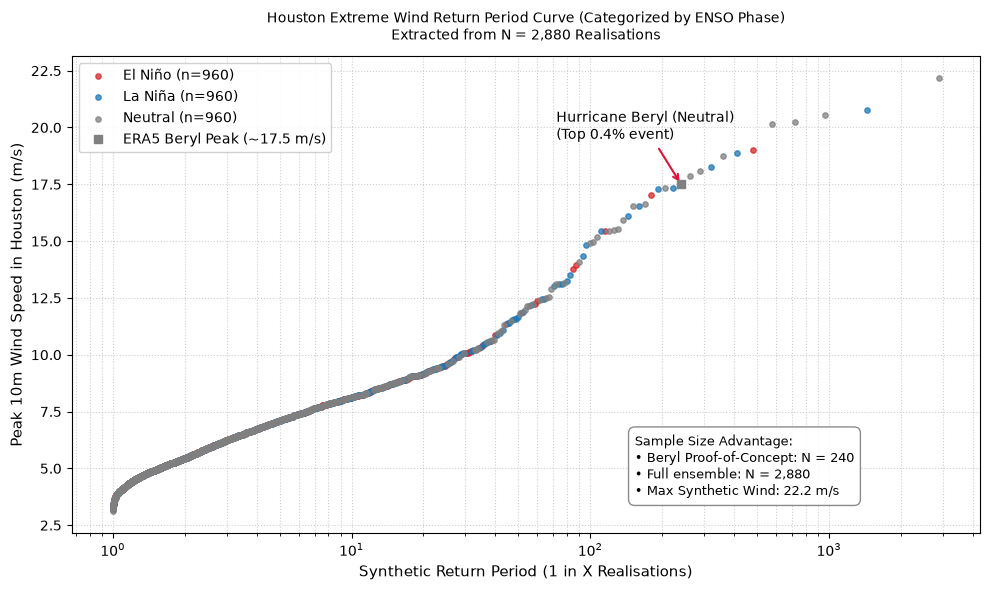

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. Prepare Houston Peak Wind Speeds & Extract Initialization Years
# -------------------------------------------------------------------------
houston_ds = houston.isel(lead_time=range(10*4, len(houston.lead_time.values))).mean(["lat", "lon"])

# Stack to get all realizations (ensemble * initialization time)
stacked = houston_ds.stack(realization=("ensemble", "time"))

# Extract maximum wind speed across lead_time
peak_da = stacked.max(dim="lead_time")
peak_winds = peak_da.values

# Extract initialization year for each realization
years = pd.to_datetime(peak_da.time.values).year
n_samples = len(peak_winds)

# -------------------------------------------------------------------------
# 2. Calculate Empirical Exceedance Probabilities & Return Periods
# -------------------------------------------------------------------------
# Sort peak winds in descending order and reorder years accordingly
sort_idx = np.argsort(peak_winds)[::-1]
sorted_winds = peak_winds[sort_idx]
sorted_years = years[sort_idx]

# Rank order (1 to N)
ranks = np.arange(1, n_samples + 1)

# Exceedance probability P(X >= x) using Weibull plotting position
exceedance_prob = ranks / (n_samples + 1)

# Return Period / Synthetic Frequency
return_period = 1 / exceedance_prob

# -------------------------------------------------------------------------
# 3. Plot Exceedance Return Period Points Grouped by ENSO Phase
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Map years to aggregated ENSO phase categories
enso_groups = {
    "El Niño": ([2002, 2015], "tab:red"),
    "La Niña": ([2010, 2020], "tab:blue"),
    "Neutral": ([2005, 2019], "gray"),
}

# Plot grouped points for each ENSO phase
for phase_name, (phase_years, color) in enso_groups.items():
    mask = np.isin(sorted_years, phase_years)
    if np.any(mask):
        ax.scatter(
            return_period[mask],
            sorted_winds[mask],
            color=color,
            s=15,
            alpha=0.75,
            label=f"{phase_name} (n={mask.sum()})",
            zorder=3,
        )

# Fallback plot for any unclassified years if present
classified_years = [y for yrs, _ in enso_groups.values() for y in yrs]
other_mask = ~np.isin(sorted_years, classified_years)
if np.any(other_mask):
    ax.scatter(
        return_period[other_mask],
        sorted_winds[other_mask],
        color="lightgray",
        s=10,
        alpha=0.5,
        label=f"Other Years (n={other_mask.sum()})",
        zorder=2,
    )

# Set logarithmic scale on X-axis to emphasize rare tail events
ax.set_xscale("log")

# -------------------------------------------------------------------------
# 4. Highlight Beryl & Key Risk Thresholds
# -------------------------------------------------------------------------
beryl_obs_wind = 17.5

# # Reference wind thresholds
# ax.axhline(
#     17.5,
#     color="gray",
#     linestyle="--",
#     linewidth=1,
#     alpha=0.7,
#     label="ERA5 Beryl (17.5 m/s)",
# )
# ax.axhline(
#     19.4,
#     color="darkorange",
#     linestyle="--",
#     linewidth=1,
#     alpha=0.7,
#     label="HENS-SFNO Beryl max (19.4 m/s)",
# )

# Highlight Beryl on the curve
if beryl_obs_wind <= sorted_winds.max():
    idx = np.argmin(np.abs(sorted_winds - beryl_obs_wind))
    beryl_rp = return_period[idx]

    ax.plot(
        beryl_rp,
        beryl_obs_wind,
        marker="s",
        color="gray",
        markersize=6,
        ls="None",
        zorder=5,
        label=f"ERA5 Beryl Peak (~{beryl_obs_wind} m/s)",
    )

    # Annotate Beryl
    ax.annotate(
        f"Hurricane Beryl (Neutral)\n(Top {exceedance_prob[idx]*100:.1f}% event)",
        xy=(beryl_rp, beryl_obs_wind),
        xytext=(beryl_rp * 0.3, beryl_obs_wind + 2),
        arrowprops=dict(arrowstyle="->", color="crimson", linewidth=1.5),
        fontsize=10,
        color="k",
    )

# -------------------------------------------------------------------------
# 5. Formatting & Annotations
# -------------------------------------------------------------------------
ax.set_xlabel("Synthetic Return Period (1 in X Realisations)", fontsize=11)
ax.set_ylabel("Peak 10m Wind Speed in Houston (m/s)", fontsize=11)
ax.set_title(
    f"Houston Extreme Wind Return Period Curve (Categorized by ENSO Phase)\nExtracted from N = {n_samples:,} Realisations",
    fontsize=10,
    pad=12,
)

# Position callout box in lower right to prevent obscuring legend/data
ax.text(
    0.62,
    0.08,
    f"Sample Size Advantage:\n• Beryl Proof-of-Concept: N = 240\n• Full ensemble: N = {n_samples:,}\n• Max Synthetic Wind: {sorted_winds.max():.1f} m/s",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

### Worst event

EXTREME TAIL EVENT IDENTIFIED (Top-Right RP Point):
• Peak Houston Wind Speed: 22.18 m/s
• Ensemble Member: 69
• Initialization Date: 2005-07-01 00:00
• Occurrence Lead Time: Day 10.25 (Step 1)


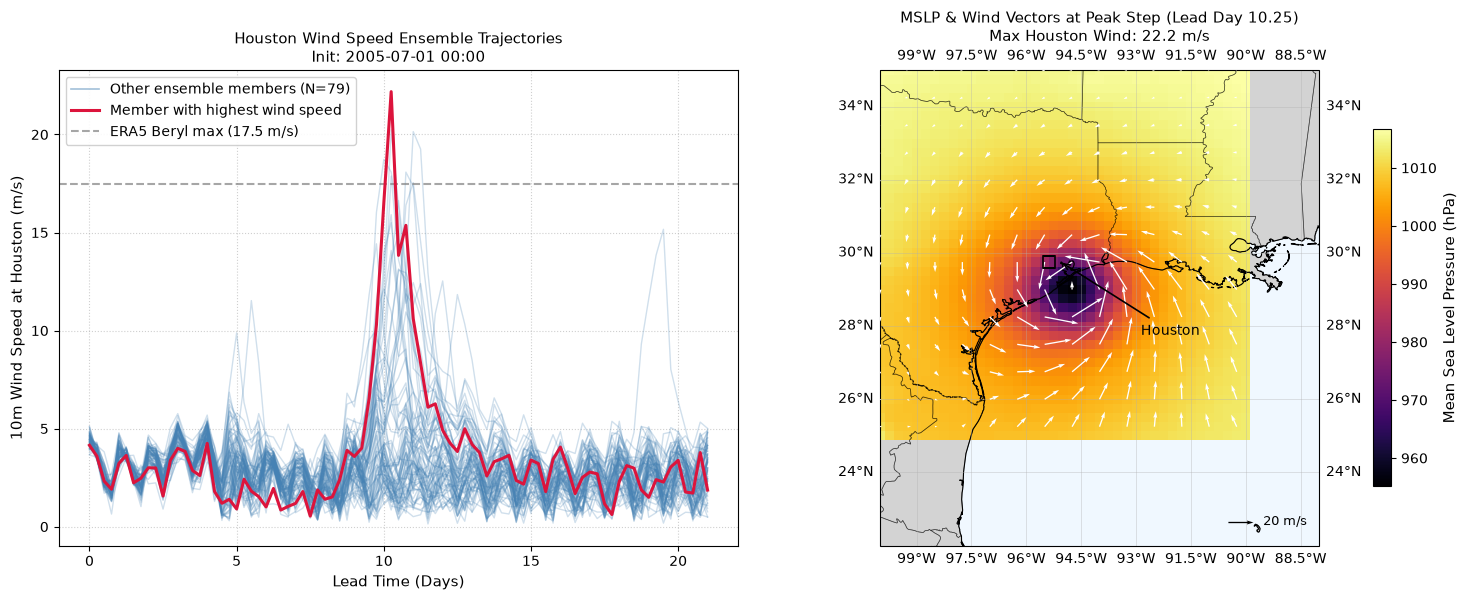

In [84]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. Identify the Forecast Realization & Step with the Highest Houston Wind Speed
# -------------------------------------------------------------------------
# Spatial average over Houston grid box
houston_ds = (
    houston.mean(["lat", "lon"]) if "lat" in houston.dims else houston
)

# Stack to unroll into individual 1D realization trajectories
stacked_houston = houston_ds.stack(realization=("ensemble", "time"))

# Optional: Slice to post spin-up lead times if applied in your analysis (e.g. days 10+)
stacked_houston_independent = houston_ds.isel(lead_time=slice(10*4, None)).stack(realization=("ensemble", "time"))
houston_for_event_id = stacked_houston_independent.copy() # For sliced

# Find the maximum value across lead_time and its 2D location (realization, lead_time)
max_wind_val = houston_for_event_id.max().values.item()
max_indices = houston_for_event_id.argmax(dim=["realization", "lead_time"])

best_realization_idx = max_indices["realization"].values.item()
best_lead_step_idx = max_indices["lead_time"].values.item()

# Extract coordinate metadata for the extreme event
best_realization = houston_for_event_id.realization.values[best_realization_idx]
best_ensemble = best_realization[0]  # Ensemble member ID
best_time = best_realization[1]  # Initialization date/time
best_lead_time = houston_for_event_id.lead_time.values[best_lead_step_idx]

best_time_str = pd.to_datetime(best_time).strftime("%Y-%m-%d %H:%M")
best_lead_days = best_lead_time / np.timedelta64(1, "D")

print("=" * 60)
print(f"EXTREME TAIL EVENT IDENTIFIED (Top-Right RP Point):")
print(f"• Peak Houston Wind Speed: {max_wind_val:.2f} m/s")
print(f"• Ensemble Member: {best_ensemble}")
print(f"• Initialization Date: {best_time_str}")
print(
    f"• Occurrence Lead Time: Day {best_lead_days:.2f} (Step {best_lead_step_idx})"
)
print("=" * 60)

# -------------------------------------------------------------------------
# 2. Extract Data for Target Initialization Window (All Members & Peak Step)
# -------------------------------------------------------------------------
# Extract all 80 ensemble member time series for the best initialization time
all_ens_ts = houston_ds.sel(time=best_time).values  # Shape: (ensemble, lead_time)
lead_days_axis = houston_ds.lead_time.values / np.timedelta64(1, "D")

# Extract spatial MSLP (converted Pa to hPa if needed) & wind components for the peak step
spatial_step = tx.sel(ensemble=best_ensemble, time=best_time, lead_time=best_lead_time)

msl_val = spatial_step['msl'].values
# Convert Pa to hPa if mean pressure is > 2000
if np.nanmean(msl_val) > 2000:
    msl_val = msl_val / 100.0

u_val = spatial_step['u10m'].values
v_val = spatial_step['v10m'].values

lats = spatial_step.lat.values
lons = spatial_step.lon.values
lons = np.where(lons > 180, lons - 360, lons)

# -------------------------------------------------------------------------
# 3. Figure Setup: Combined Time Series and Spatial Map
# -------------------------------------------------------------------------
projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(15, 6))

# --- Subplot 1: Houston Wind Speed Time Series (All Ensemble Members) ---
ax1 = fig.add_subplot(1, 2, 1)

# Plot all other ensemble members in the background
num_members = all_ens_ts.shape[0]
for ens_idx in range(num_members):
    if ens_idx == best_ensemble:
        continue
    ax1.plot(lead_days_axis, all_ens_ts[ens_idx, :], color="steelblue", alpha=0.25, linewidth=1.0)

ax1.plot([], [], color="steelblue", alpha=0.5, linewidth=1.2, label=f"Other ensemble members (N={num_members-1})")

# Highlight worst-case member on top
target_ts = all_ens_ts[best_ensemble, :]
ax1.plot(
    lead_days_axis,
    target_ts,
    color="crimson",
    linewidth=2.2,
    zorder=5,
    # label=f"Member {best_ensemble} ({best_time_str})",
    label="Member with highest wind speed"
)
# ax1.plot(
#     best_lead_days,
#     max_wind_val,
#     marker="o",
#     markersize=8,
#     color="black",
#     zorder=6,
#     label=f"Peak: {max_wind_val:.1f} m/s",
# )

ax1.axhline(
    17.5,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="ERA5 Beryl max (17.5 m/s)",
)
ax1.set_xlabel("Lead Time (Days)", fontsize=11)
ax1.set_ylabel("10m Wind Speed at Houston (m/s)", fontsize=11)
ax1.set_title(
    f"Houston Wind Speed Ensemble Trajectories\nInit: {best_time_str}",# | Ensemble member with highest wind speed: {best_ensemble}",
    fontsize=11,
)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left", framealpha=0.9)

# --- Subplot 2: MSLP Field Map with Overlaid Wind Vectors ---
ax2 = fig.add_subplot(1, 2, 2, projection=projection)

ax2.set_extent([-100, -88, 22, 35], crs=projection)
ax2.add_feature(cfeature.LAND, facecolor="lightgray")
ax2.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.7)
ax2.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)

# Contour mesh for MSLP
mesh = ax2.pcolormesh(
    lons,
    lats,
    msl_val,
    cmap="inferno",  # Reversed Blues puts lowest pressure (cyclone center) in dark blue/purple
    shading="auto",
    transform=projection,
)

cbar = fig.colorbar(
    mesh, ax=ax2, orientation="vertical", shrink=0.75, pad=0.08
)
cbar.set_label("Mean Sea Level Pressure (hPa)", fontsize=11)

# Overlay wind vectors (subsampled by step=3 for legibility)
step = 3
quiv = ax2.quiver(
    lons[::step],
    lats[::step],
    u_val[::step, ::step],
    v_val[::step, ::step],
    color="white",
    scale=350,
    width=0.003,
    transform=projection,
    zorder=6,
)
ax2.quiverkey(
    quiv, X=0.85, Y=0.05, U=20, label="20 m/s", labelpos="E",
    coordinates="axes", color="black", facecolor="white", fontproperties={"size": 9}
)

# Annotate Houston location
houston_lon, houston_lat = -95.37, 29.76
ax2.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="black",
    markerfacecolor="None",
    markersize=8,
    markeredgewidth=1.2,
    zorder=8,
    transform=projection,
)

ax2.annotate(
    "Houston",
    xy=(houston_lon + 0.3, houston_lat),
    xytext=(houston_lon + 2.5, houston_lat - 2.0),
    xycoords=projection._as_mpl_transform(ax2),
    textcoords=projection._as_mpl_transform(ax2),
    fontsize=10,
    # fontweight="bold",
    color="black",
    zorder=9,
    arrowprops=dict(
        arrowstyle="->", color="black", linewidth=1.2, shrinkA=5
    ),
)

ax2.set_title(
    f"MSLP & Wind Vectors at Peak Step (Lead Day {best_lead_days:.2f})\nMax Houston Wind: {max_wind_val:.1f} m/s",
    fontsize=11,
)
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [85]:
import pandas as pd

# -------------------------------------------------------------------------
# Extract Top 10 Worst Peak Wind Events in Houston
# -------------------------------------------------------------------------
# Ensure data is spatial-averaged over Houston and unrolled into 1D realizations
houston_ds = (
    houston.mean(["lat", "lon"]) if "lat" in houston.dims else houston
)

# Optional: Apply post spin-up lead time slice if evaluating independent tail risk
# houston_ds = houston_ds.isel(lead_time=slice(10 * 4, None))

# Find the peak wind speed per realization trajectory (across lead_time)
peak_winds_per_realization = houston_ds.max(dim="lead_time")

# Convert to DataFrame and sort to get the top 10
df_peaks = (
    peak_winds_per_realization.to_dataframe(name="peak_wind")
    .reset_index()
    .sort_values(by="peak_wind", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Format initialization date for display
df_peaks["init_date"] = pd.to_datetime(df_peaks["time"]).dt.strftime(
    "%Y-%m-%d %H:%M"
)

# Print clean report table
print("=" * 65)
print(f"{'Rank':<5} | {'Init Date':<17} | {'Ensemble':<8} | {'Peak Wind (m/s)':<15}")
print("-" * 65)
for idx, row in df_peaks.iterrows():
    print(
        f"{idx+1:<5} | {row['init_date']:<17} | {int(row['ensemble']):<8} | {row['peak_wind']:.2f} m/s"
    )
print("=" * 65)

Rank  | Init Date         | Ensemble | Peak Wind (m/s)
-----------------------------------------------------------------
1     | 2005-07-01 00:00  | 69       | 22.18 m/s
2     | 2010-09-01 00:00  | 55       | 20.79 m/s
3     | 2005-09-01 00:00  | 33       | 20.57 m/s
4     | 2005-07-01 00:00  | 33       | 20.24 m/s
5     | 2005-07-01 00:00  | 64       | 20.15 m/s
6     | 2020-06-01 00:00  | 70       | 20.00 m/s
7     | 2002-09-01 00:00  | 74       | 19.01 m/s
8     | 2010-08-01 00:00  | 75       | 18.87 m/s
9     | 2005-07-01 00:00  | 15       | 18.73 m/s
10    | 2010-08-01 00:00  | 71       | 18.26 m/s
